In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv("data/raw/titanic_raw_data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

df.drop("Cabin", axis=1, inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

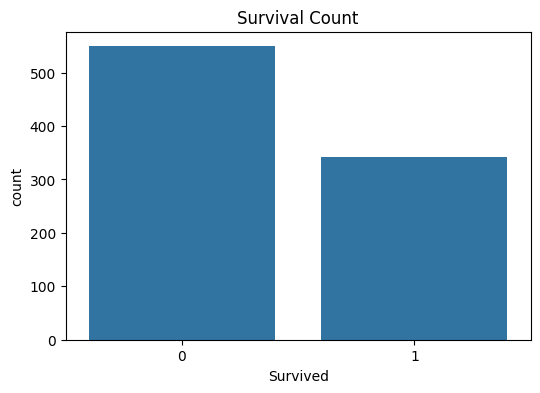

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Survived",
    data=df
)

plt.title("Survival Count")

plt.show()

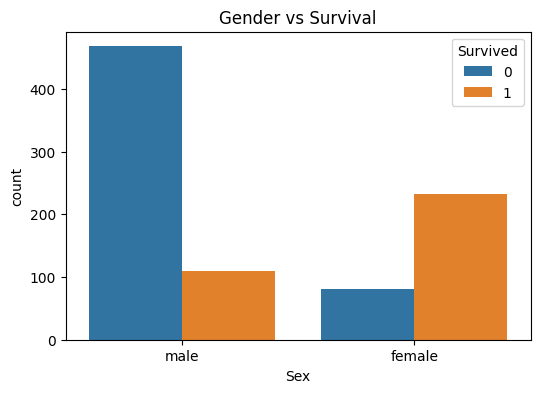

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Gender vs Survival")

plt.show()

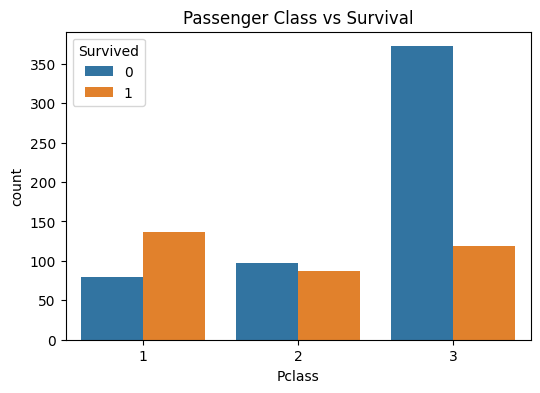

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.title("Passenger Class vs Survival")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

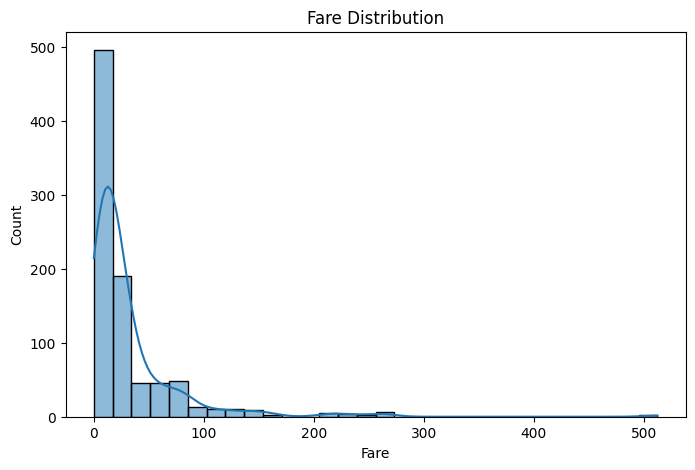

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Fare"],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")

plt.show()

In [15]:
df_corr = df.copy()


encoder = LabelEncoder()

df_corr["Sex"] = encoder.fit_transform(
    df_corr["Sex"]
)

df_corr["Embarked"] = encoder.fit_transform(
    df_corr["Embarked"]
)

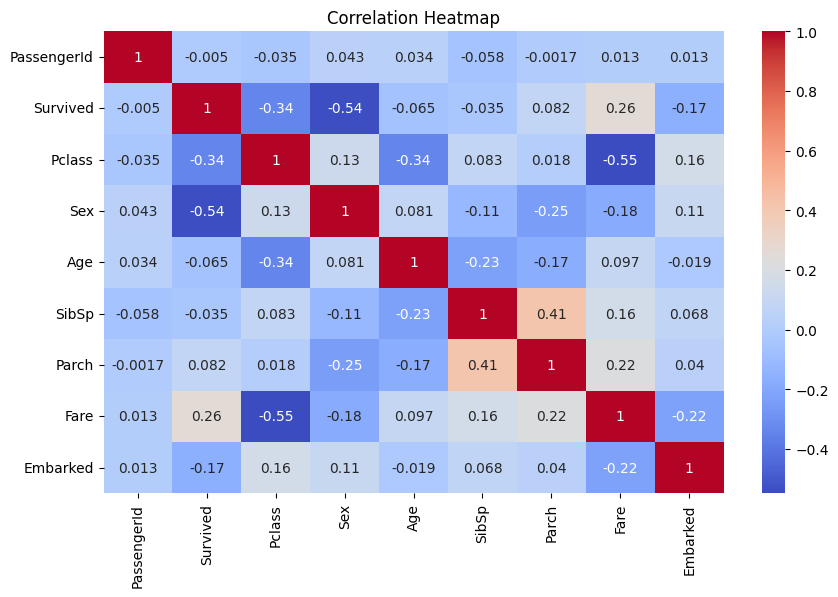

In [16]:
df_corr = df_corr.drop(
    columns=[
        "Name",
        "Ticket"
    ]
)
plt.figure(figsize=(10,6))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
survival_class = df.groupby(
    "Pclass"
)["Survived"].mean()

print(survival_class)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [18]:
survival_gender = df.groupby(
    "Sex"
)["Survived"].mean()

print(survival_gender)


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [ ]:
''' Conclusion

1. Female passengers had significantly higher survival rates.

2. First-class passengers had better chances of survival than lower classes.

3. Most missing values were found in the Cabin column, so it was removed.

4. Age and Embarked missing values were handled successfully.

5. Passenger class and gender were among the strongest factors affecting survival.

6. The dataset was cleaned and analyzed successfully using Python, Pandas, Matplotlib, and Seaborn.'''
